# 🎞️ Lab: The 35mm Exposure & Development Test

### Welcome, Photographers!
To master black and white photography, you cannot just rely on the ISO number printed on the film box. [cite_start]You have to find the exact film speed and development time that works best for *your* specific camera, your lenses, and your darkroom chemistry[cite: 444]. 

[cite_start]This procedure tests how both exposure and development time affect your shadows and highlights[cite: 443]. [cite_start]While you could test this on a plain gray "tone cube," it is much more fun to use a real, pleasing scene[cite: 442]. 

### 🎒 Equipment & Preparation
To do this right, we need to eliminate as many random variables as possible.

* [cite_start]**The Film:** You will need one entire roll of 36-exposure film[cite: 445].
* **The Tripod:** This is highly recommended! [cite_start]A tripod allows you to concentrate entirely on the scientific procedure without accidentally changing your composition between shots[cite: 448].
* [cite_start]**The Environment:** You must choose a day when the light is completely constant[cite: 459, 461]. [cite_start]If there are clouds moving across the sun, wait for them to pass[cite: 462]. [cite_start]The quantity and quality of light must not change, and the whole test should take about 10 to 15 minutes[cite: 460, 463].

### 📏 The Rule of Metering: No Matrix Allowed!
[cite_start]To measure the light, a Spot Meter is highly recommended because it lets you measure very specific, tiny areas of your frame[cite: 449, 450]. [cite_start]Incident or averaging meters work too[cite: 451]. 

[cite_start]However, you must **turn off your camera's Matrix or Evaluative metering system**[cite: 452]. 
Why? Because advanced matrix meters are designed to guess what you are shooting and change their reading automatically. [cite_start]If the camera detects a bright highlight, it might suddenly alter the exposure[cite: 456]. [cite_start]For a scientific test, your meter must be strictly linear, repeatable, and accurate[cite: 453, 454, 458]. [cite_start]If you can't turn matrix metering off, set it to a standard "normal" or center-weighted pattern[cite: 458]. 


### 🎞️ Loading the Camera
We are going to be cutting this film in the darkroom later, so we need to know exactly where the frames start. 
1. Pull the film across the back of the camera.
2. [cite_start]Before you close the back, use a permanent marker to draw a line on the film exactly along the right edge of the camera's film aperture (the opening behind the shutter)[cite: 465].
3. Close the back and advance the film. [cite_start]Note exactly how many frames you advance (usually it takes 3 frames to reach counter #1)[cite: 466, 467]. [cite_start]This ensures you can measure and cut the film in total darkness later[cite: 447].

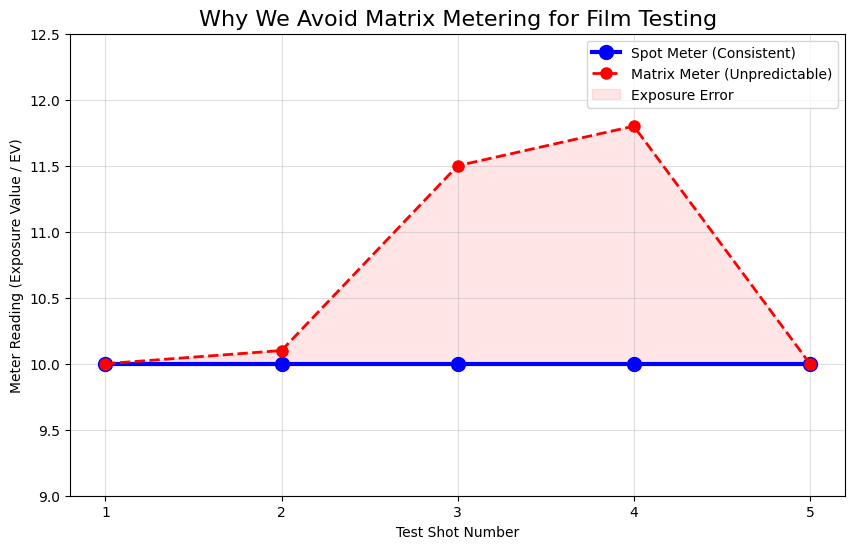

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def simulate_metering_consistency():
    """
    Simulates why Matrix metering ruins scientific exposure tests compared to Spot metering.
    We simulate taking 5 consecutive photos of a test target while a bright cloud moves in the background.
    """
    shots = np.arange(1, 6)
    
    # The actual light falling on our test subject remains exactly the same (EV 10)
    actual_subject_light = np.full(5, 10.0) 
    
    # SPOT METER: Only reads the subject. It is perfectly consistent and repeatable.
    spot_meter_readings = np.full(5, 10.0)
    
    # MATRIX METER: Reads the whole scene. 
    # As a bright cloud moves into the background on shots 3 and 4, 
    # the matrix meter gets tricked and artificially lowers the exposure reading.
    matrix_meter_readings = np.array([10.0, 10.1, 11.5, 11.8, 10.0])
    
    plt.figure(figsize=(10, 6))
    plt.plot(shots, spot_meter_readings, 'bo-', lw=3, markersize=10, label="Spot Meter (Consistent)")
    plt.plot(shots, matrix_meter_readings, 'ro--', lw=2, markersize=8, label="Matrix Meter (Unpredictable)")
    
    # Fill the area where the Matrix meter fails
    plt.fill_between(shots, spot_meter_readings, matrix_meter_readings, color='red', alpha=0.1, label="Exposure Error")
    
    plt.title("Why We Avoid Matrix Metering for Film Testing", fontsize=16)
    plt.xlabel("Test Shot Number")
    plt.ylabel("Meter Reading (Exposure Value / EV)")
    plt.xticks(shots)
    plt.ylim(9, 12.5)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()

# Run the metering simulation!
simulate_metering_consistency()